# 02 - eda (sample)

visualize sample data: class distribution, waveforms, mel spectrograms.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

import sys
sys.path.append('../../')
from src.config.settings import SAMPLES, FIGURES_DIR

In [2]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
df = pd.read_csv(SAMPLES / "sample_labels.csv")
df.head()

,filepath,channel,emotion_code,emotion,intensity,statement,repetition,actor,gender,split
0,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,1,1,23,male,test
1,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,1,2,23,male,test
2,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,2,1,23,male,test
3,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,2,2,23,male,test
4,/mnt/d/career/projects/lightweight-speech-emot...,song,2,calm,normal,1,1,23,male,test


In [3]:
print(f"{len(df)} sample files loaded")

416 sample files loaded


### emotion distribution

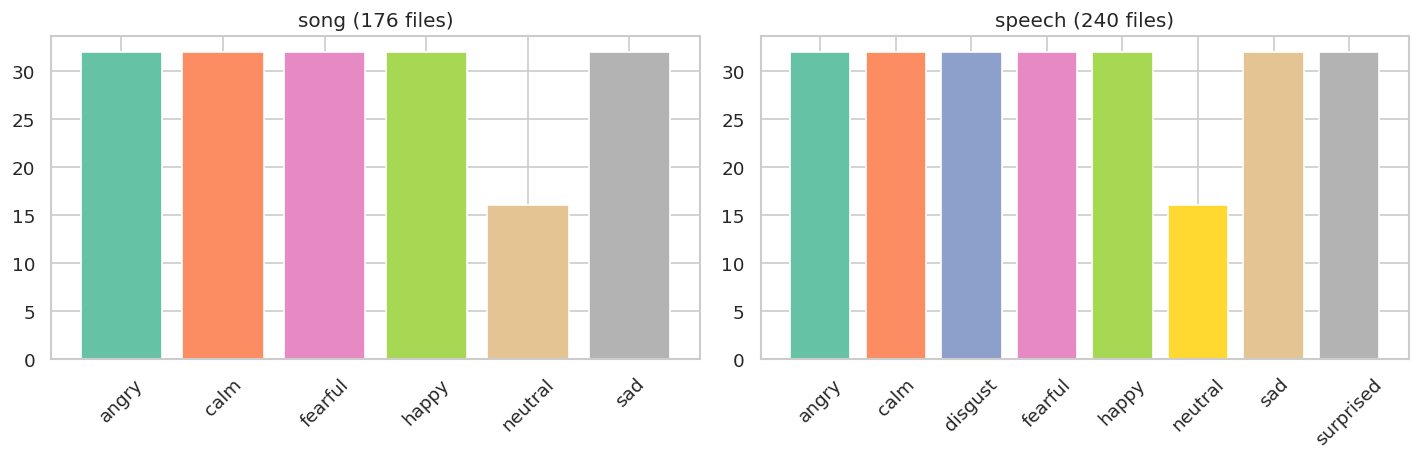

In [4]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax,(ch,sub) in zip(axes, df.groupby('channel')):
    c = sub['emotion'].value_counts().sort_index()
    ax.bar(c.index, c.values, color=plt.cm.Set2(np.linspace(0,1,len(c))))
    ax.set_title(f'{ch} ({len(sub)} files)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'fig03-emotion-distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

### sample waveforms

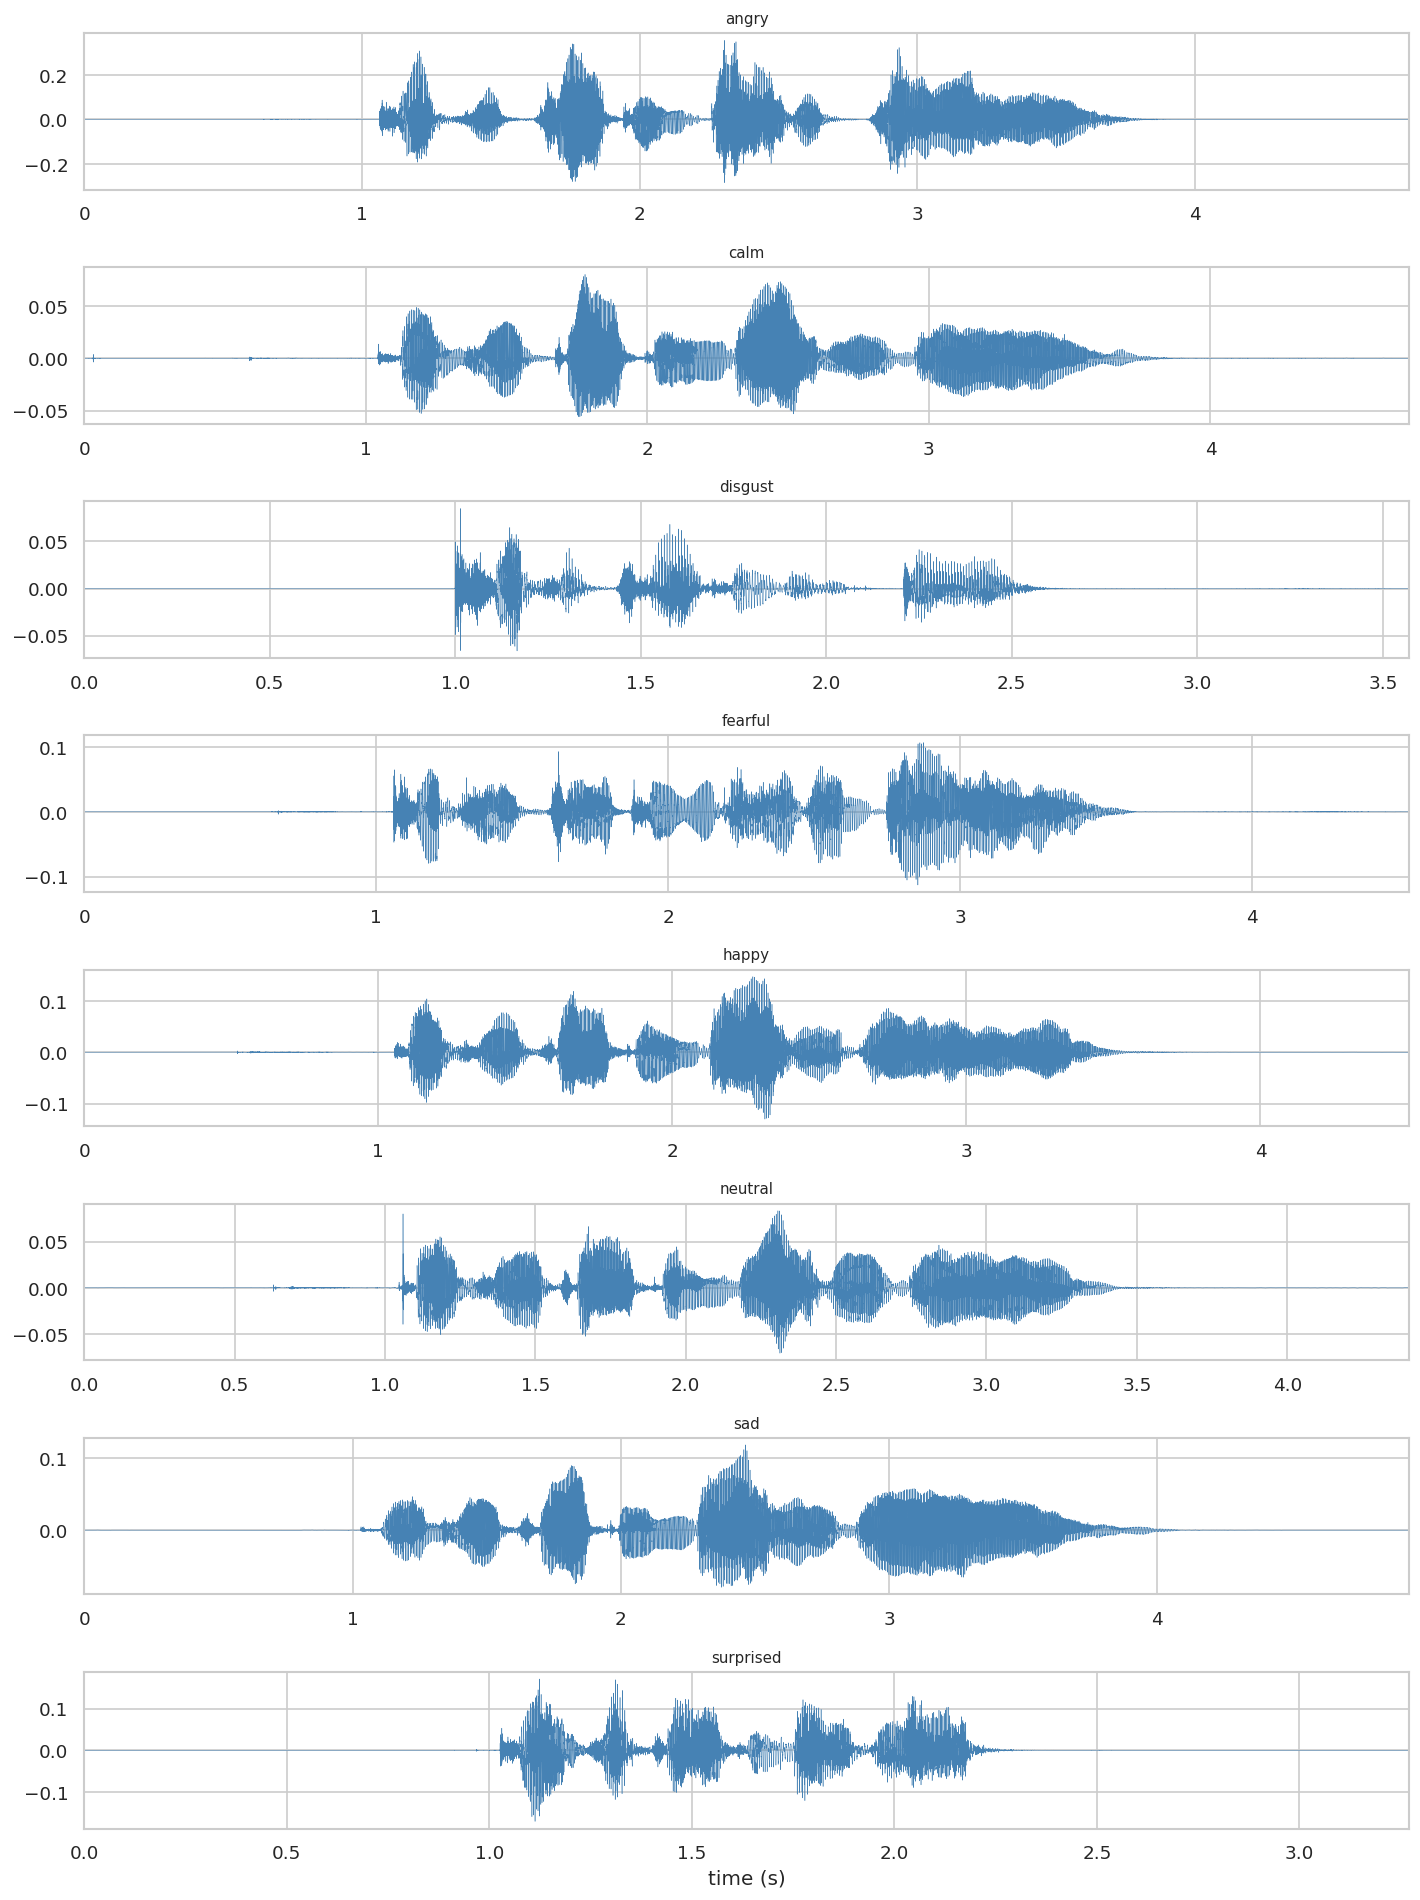

In [5]:
samples = df.groupby('emotion').first().reset_index()
fig, axes = plt.subplots(len(samples), 1, figsize=(12, 2*len(samples)))
for i,(_,row) in enumerate(samples.iterrows()):
    y,sr = librosa.load(row['filepath'])
    t = np.arange(len(y))/sr
    axes[i].plot(t, y, linewidth=0.3, color='steelblue')
    axes[i].set_title(f"{row['emotion']}", fontsize=9)
    axes[i].set_xlim(0, min(5, t[-1]))
plt.xlabel('time (s)')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'fig04-sample-waveforms.png'), dpi=120, bbox_inches='tight')
plt.show()

### mel spectrograms

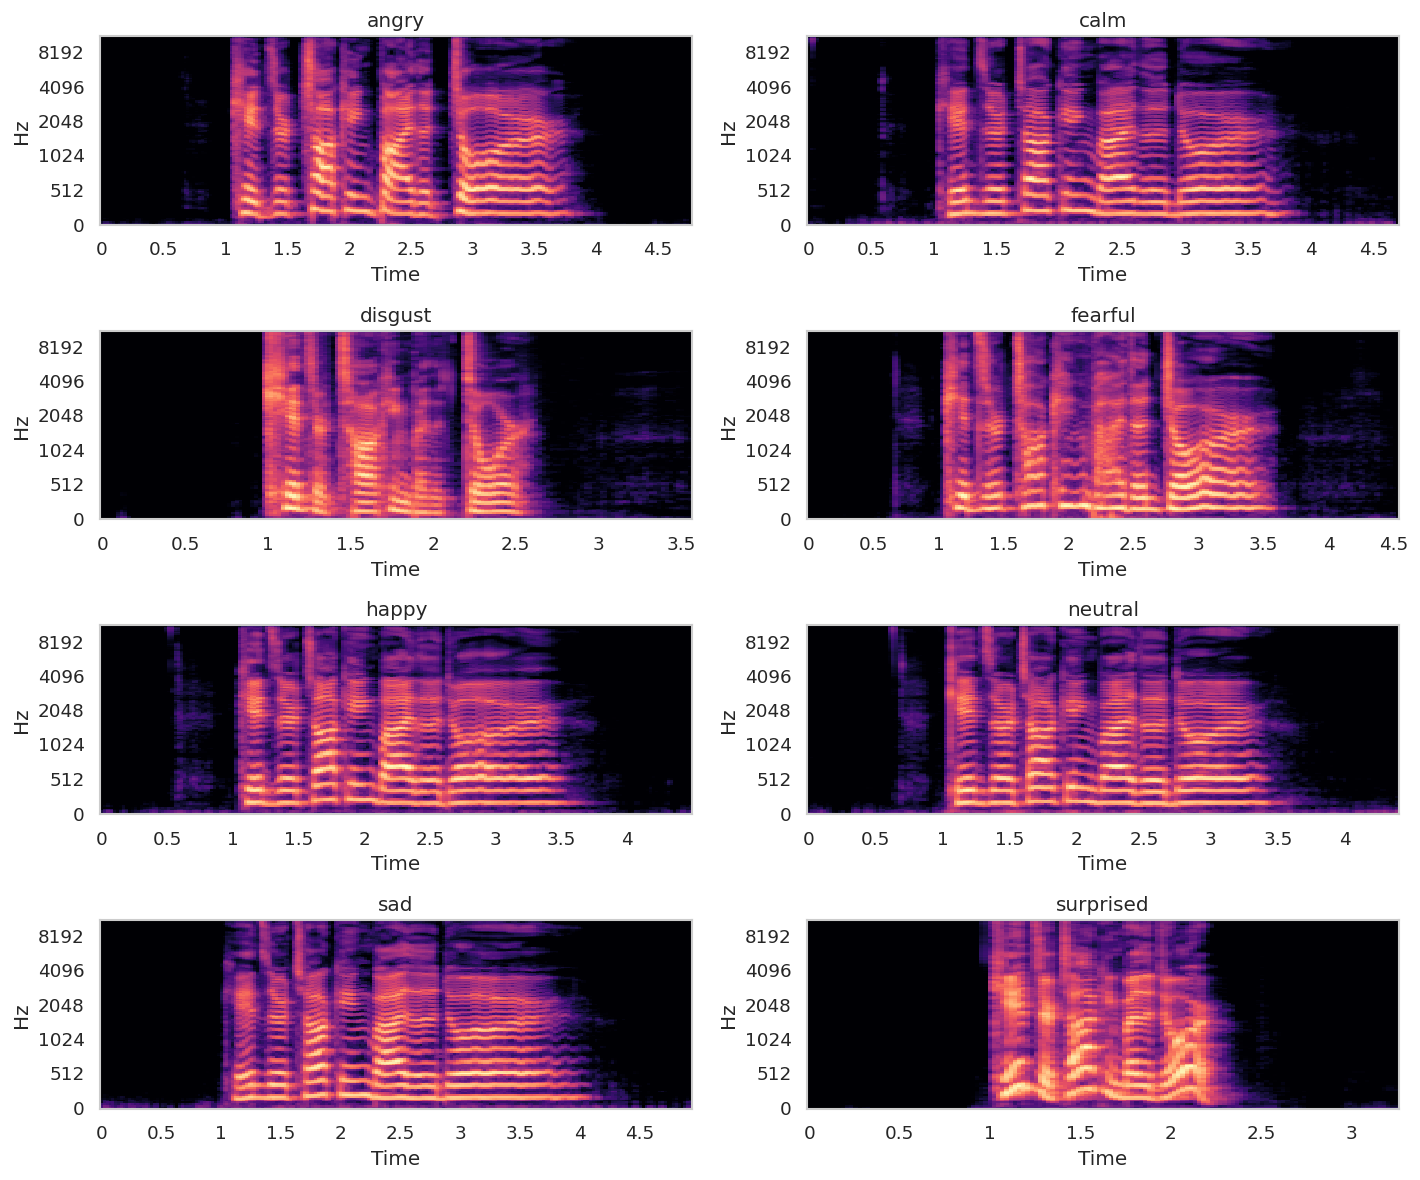

In [6]:
fig, axes = plt.subplots(4,2,figsize=(12,10))
axes = axes.flatten()
for i,(_,row) in enumerate(samples.head(8).iterrows()):
    y,sr = librosa.load(row['filepath'])
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    logmel = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(logmel, x_axis='time', y_axis='mel', sr=sr, ax=axes[i])
    axes[i].set_title(f"{row['emotion']}")
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'fig05-mel-spectrograms.png'), dpi=120, bbox_inches='tight')
plt.show()

### duration stats

In [7]:
sample = df.sample(20, random_state=42)
durs = []
for fp in sample['filepath']:
    y,sr = librosa.load(fp, duration=10)
    durs.append(len(y)/sr)
durs = np.array(durs)
print(f"duration: min={durs.min():.2f}s max={durs.max():.2f}s mean={durs.mean():.2f}s")

duration: min=3.14s max=5.71s mean=4.04s


eda done on sample data.